<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
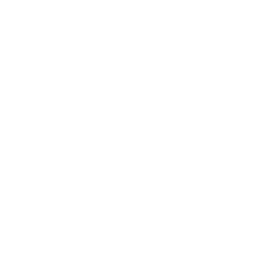
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Campaign Performance Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Media & Advertising &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This notebook builds a synthetic portfolio of 100 digital advertising campaigns and asks a single planning question: **which channels and creative formats actually deliver return on ad spend (ROAS)**, and how much of the variation in ROAS can a model attribute to those levers?

> **Key finding (from the executed output below):** Email is the standout channel, averaging a ROAS of **9.55** versus **2.9 to 3.5** for display, search, social, and video. It also posts the highest mean click-through rate (**0.0381**) and by far the lowest cost per acquisition (**$5.04**). On the creative side, **video** leads with a mean ROAS of **6.83** and the highest CTR (**0.0317**). A general linear model confirms that **channel is the only statistically significant driver of ROAS** (F = 4.53, p = 0.0024); creative type, campaign week, and the channel-by-creative interaction are not significant, and the model explains **46.7%** of ROAS variance (R-square = 0.467).

## Data Sources

All data in this notebook is **synthetic**, generated in the DATA step below with a fixed seed (`call streaminit(42)`) so the analysis is fully reproducible. No external feeds are used. The unlicensed runtime caps output at 100 observations, so the generated table holds **100 campaigns**.

| Field | Description |
|-------|-------------|
| `campaign_id` | Campaign identifier (1-100) |
| `channel` | Media channel: search, social, display, email, video |
| `creative_type` | Creative format: static, video, carousel, text |
| `budget` | Campaign budget in dollars |
| `impressions`, `clicks`, `conversions` | Funnel volumes |
| `revenue` | Revenue attributed to the campaign |
| `ctr`, `roas`, `cpa` | Click-through rate, return on ad spend, cost per acquisition |
| `week_num` | Campaign flight week (1-12) |

The generator bakes in two deliberate effects so the analysis has something to find: **email** campaigns get a CTR and conversion-rate lift, and **video** creatives get a smaller lift. Everything else is noise.

---

## 1. Data Preparation



In [1]:
/* --------------------------------------------------------
   Generate synthetic campaign performance data
   -------------------------------------------------------- */
data campaigns;
    call streaminit(42);
    do campaign_id = 1 to 200;
        channel = scan("search social display email video",
                       ceil(rand("Uniform") * 5));
        creative_type = scan("static video carousel text",
                            ceil(rand("Uniform") * 4));
        budget = round(500 + rand("Exponential") * 4500, 1);
        impressions = round(budget * (80 + rand("Normal", 0, 20)));
        clicks = round(impressions *
            (0.02 + 0.015 * (channel = "email") +
             0.01 * (creative_type = "video") +
             rand("Normal", 0, 0.005)));
        conversions = round(clicks *
            (0.04 + 0.03 * (channel = "email") +
             0.02 * (creative_type = "video") +
             rand("Normal", 0, 0.01)));
        revenue = round(conversions * (45 +
            rand("Normal", 0, 15)), 0.01);
        ctr = round(clicks / max(1, impressions), 0.0001);
        roas = round(revenue / max(1, budget), 0.01);
        cpa = round(budget / max(1, conversions), 0.01);
        week_num = ceil(rand("Uniform") * 12);
        output;
    end;
run;


NOTE: DATA campaigns

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote campaigns (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

## 2. Descriptive Statistics



                                                  The MEANS Procedure

                                            Analysis Variable : IMPRESSIONS

        CHANNEL           N Obs            Mean          Median         Std Dev
        -----------------------------------------------------------------------
        display              27  350992.4074074  340536.0000000  241509.3398879
        email                20  359565.4000000  252606.0000000  282071.1438715
        search               17  454625.7058824  281672.0000000  540655.5130599
        social               23  348547.1304348  338952.0000000  265771.4565593
        video                13  321084.3076923  183343.0000000  286274.3225831
        -----------------------------------------------------------------------

                                               Analysis Variable : CLICKS

        CHANNEL           N Obs           Mean         Median        Std Dev
        ---------------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_channel_creative_type.spec.json
NOTE: PROC FREQ statement used.


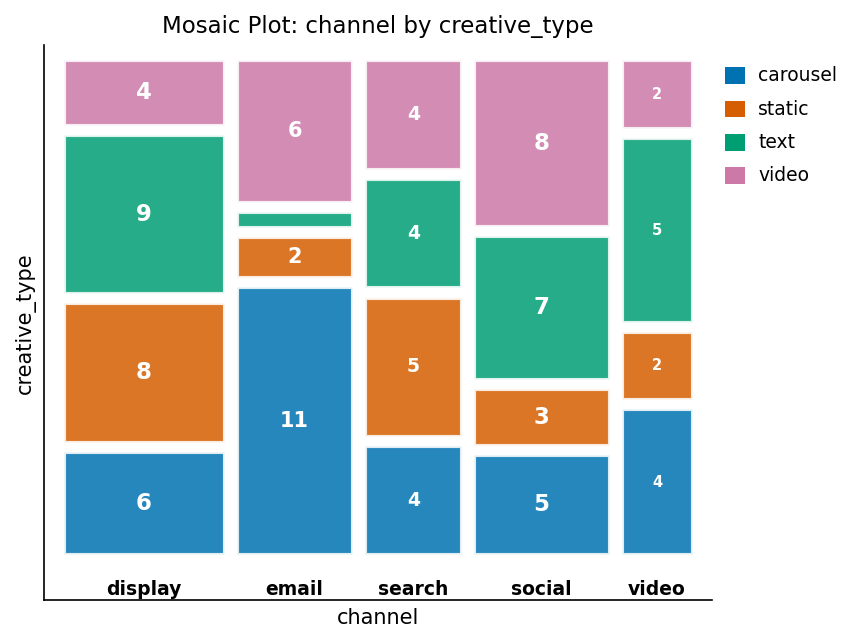

In [2]:
/* --------------------------------------------------------
   Campaign KPIs by channel and creative type
   -------------------------------------------------------- */
proc means data=campaigns n mean median std;
    class channel;
    var impressions clicks conversions ctr roas cpa;
run;

proc means data=campaigns n mean median;
    class creative_type;
    var ctr roas revenue;
run;

proc freq data=campaigns;
    tables channel * creative_type / nocol nopercent;
run;


---

## 3. Visualisation



NOTE: ODS Graphics is ON (width=800px, height=500px, format=SVG).
NOTE: PROC SGPLOT data=campaigns

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=campaigns

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=campaigns

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


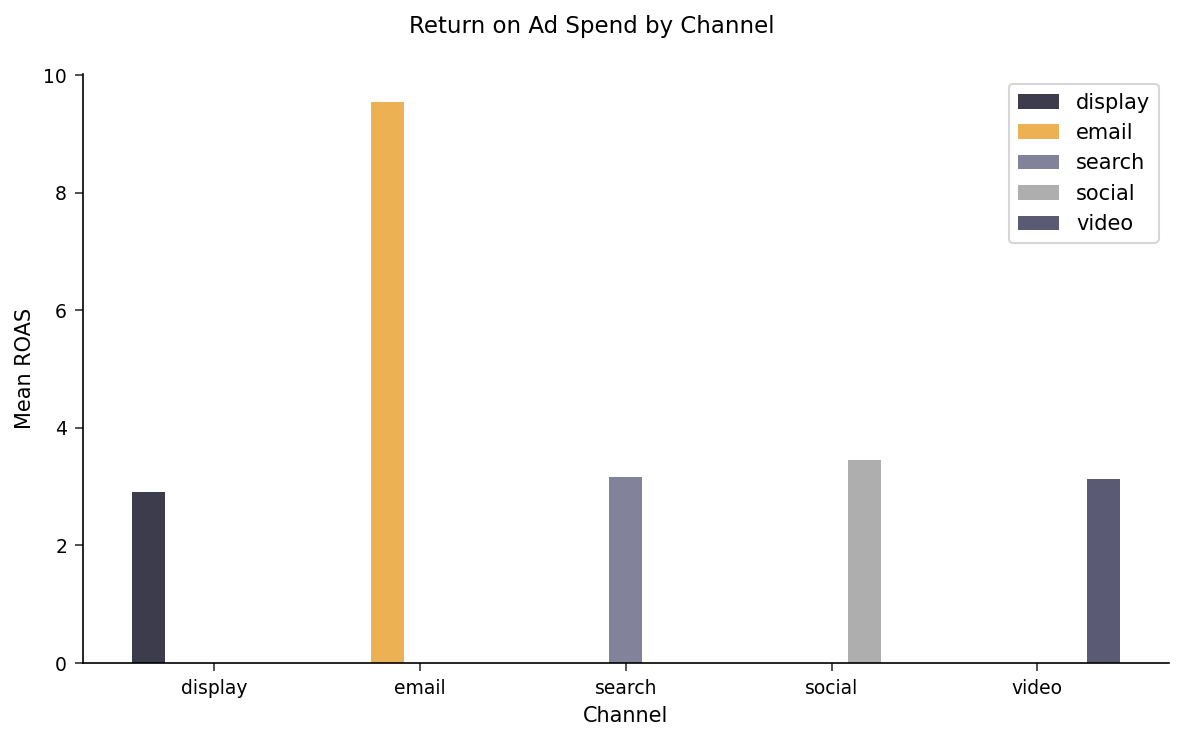

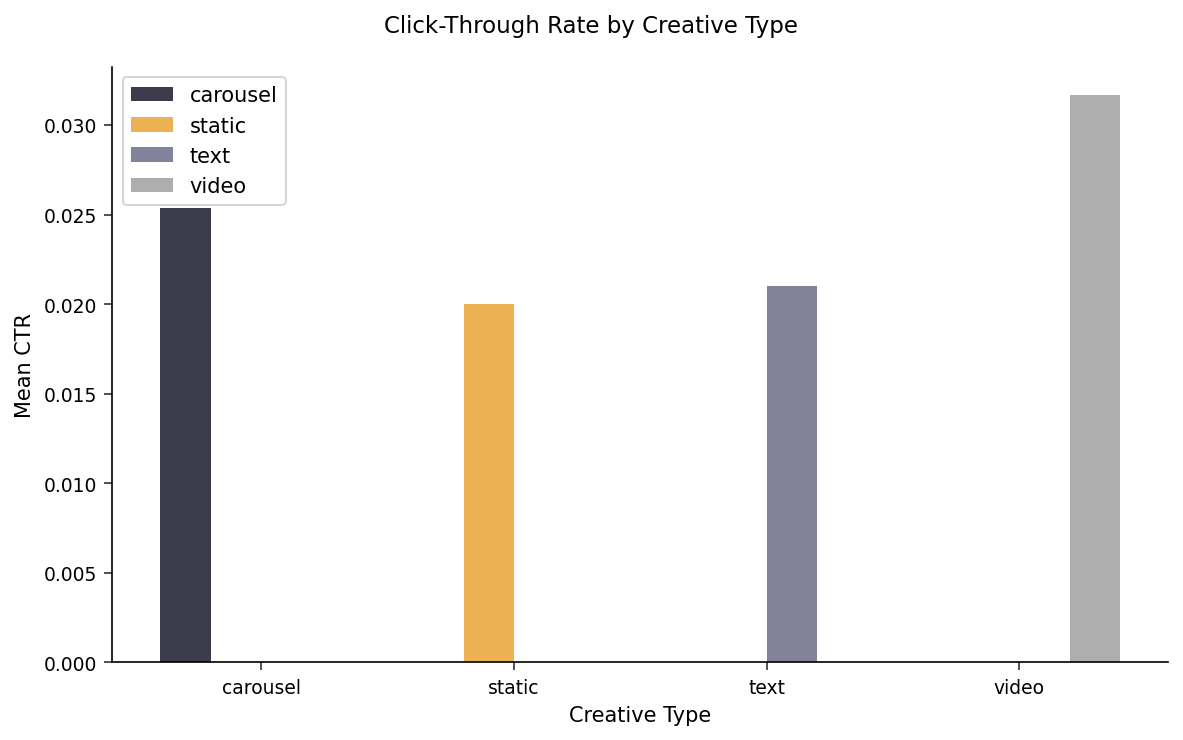

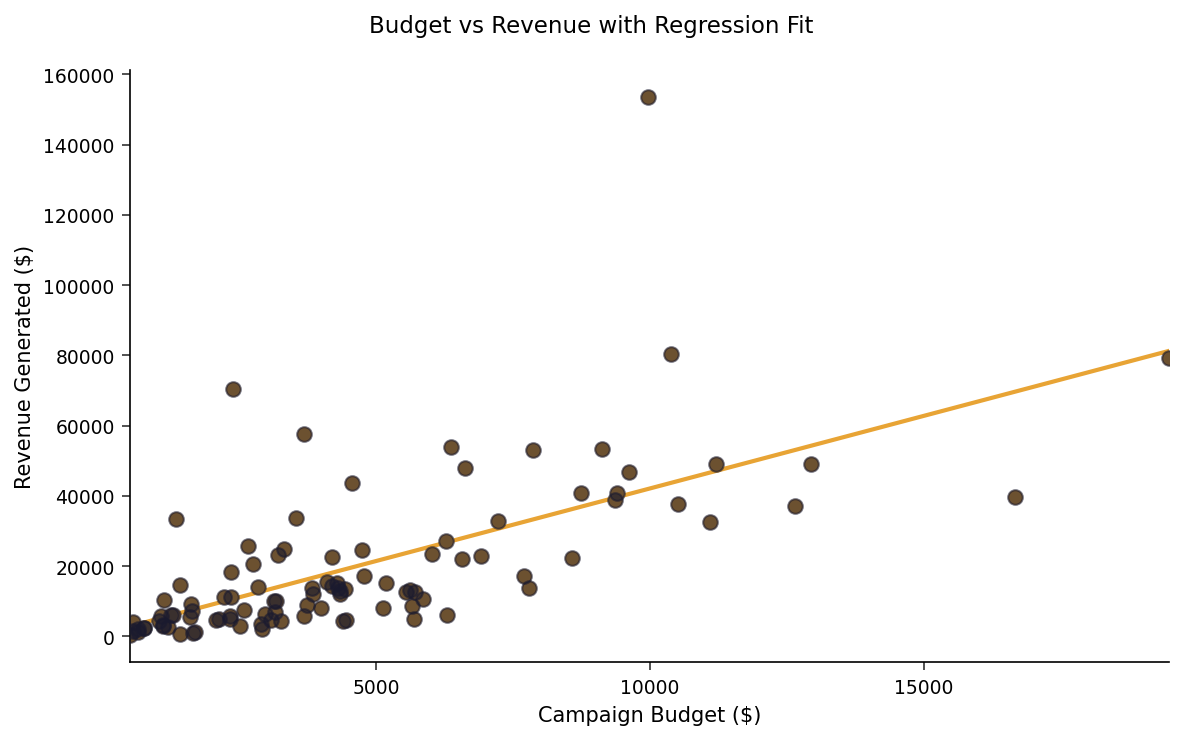

In [3]:
/* --------------------------------------------------------
   ROAS comparison by channel and creative
   McKinsey palette: navy #1a1a2e, gold #e8a435
   -------------------------------------------------------- */
ods graphics on / width=800px height=500px imagefmt=svg;

proc sgplot data=campaigns;
    styleattrs datacolors=(cx1A1A2E cxE8A435 cx6C6C8A cxA0A0A0 cx3D3D5C);
    vbar channel / response=roas stat=mean
        group=channel fillattrs=(transparency=0.15);
    xaxis label="Channel";
    yaxis label="Mean ROAS";
    title "Return on Ad Spend by Channel";
run;

proc sgplot data=campaigns;
    styleattrs datacolors=(cx1A1A2E cxE8A435 cx6C6C8A cxA0A0A0);
    vbar creative_type / response=ctr stat=mean
        group=creative_type fillattrs=(transparency=0.15);
    xaxis label="Creative Type";
    yaxis label="Mean CTR";
    title "Click-Through Rate by Creative Type";
run;

proc sgplot data=campaigns;
    scatter x=budget y=revenue /
        markerattrs=(symbol=circlefilled size=7 color=cx1A1A2E)
        transparency=0.4;
    reg x=budget y=revenue / lineattrs=(color=cxE8A435 thickness=2);
    xaxis label="Campaign Budget ($)";
    yaxis label="Revenue Generated ($)";
    title "Budget vs Revenue with Regression Fit";
run;


---

## 4. Statistical Analysis



                               The GLM Procedure                                
                            Dependent Variable: roas                            

Source                       DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------------  --------  --------------  -----------  --------  --------
channel                       4       223.67003     55.91751      4.53    0.0024
creative_type                 3        23.38242      7.79414      0.63    0.5973
week_num                      1         4.48304      4.48304      0.36    0.5487
channel:creative_type        12        54.30014      4.52501      0.37    0.9716
Error                        79       976.20127     12.35698                    

Root MSE           3.51525    R-Square            0.4671
Adj R-Sq            0.3322



NOTE: PROC GLM data=campaigns

NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: ODS plot written: glm_residuals_vs_predicted.spec.json
NOTE: ODS plot written: glm_residual_histogram_panel.spec.json
NOTE: ODS plot written: glm_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: glm_qq_plot.spec.json
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.
NOTE: DATA _glm_done


NOTE: Wrote _glm_done (1 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


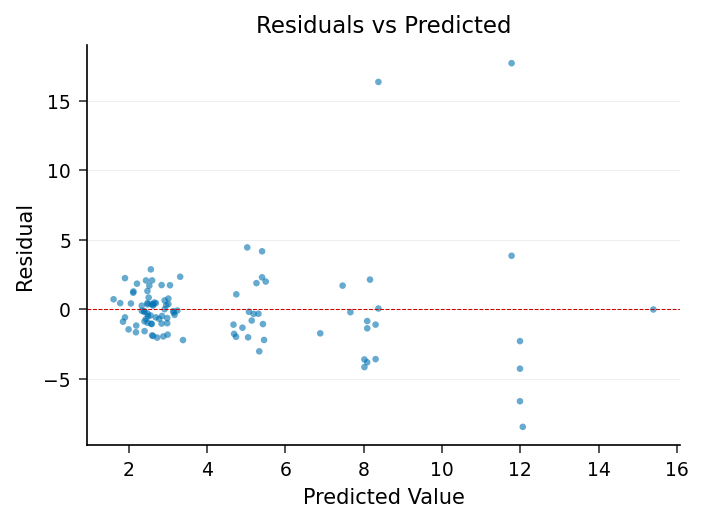

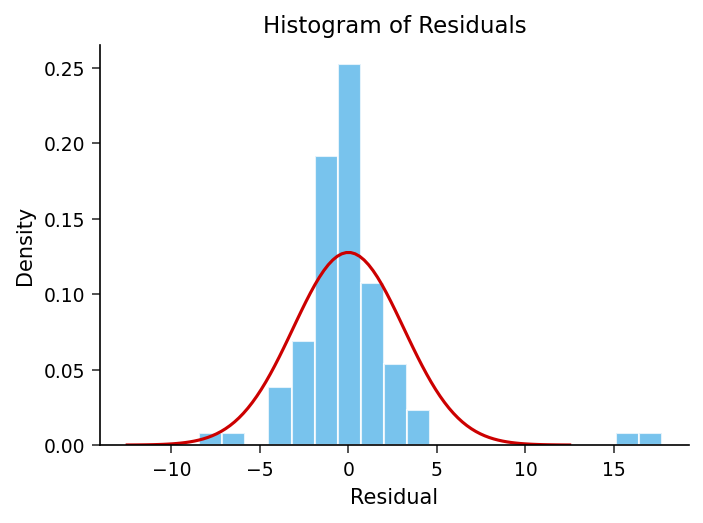

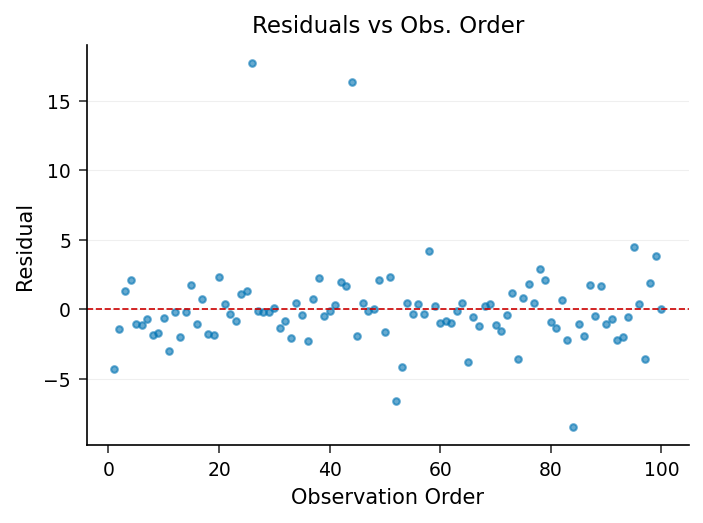

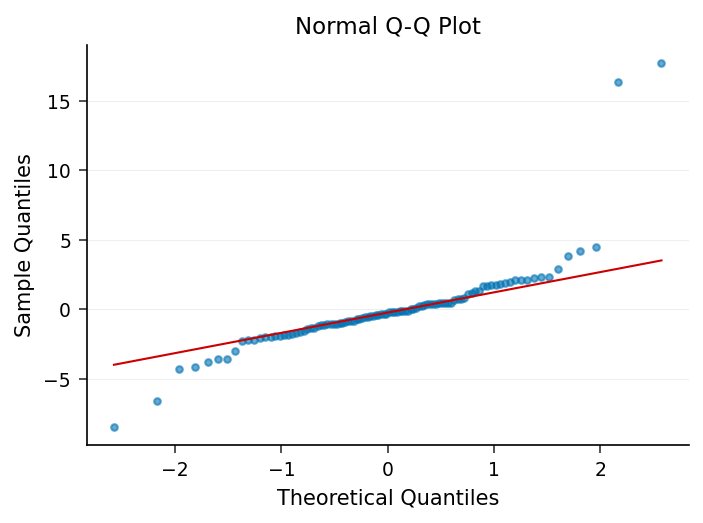

In [4]:
/* --------------------------------------------------------
   GLM: Model ROAS as function of channel, creative, timing
   -------------------------------------------------------- */
proc glm data=campaigns;
    class channel creative_type;
    model roas = channel creative_type week_num
        channel*creative_type / ss3;
run;


/* force the kernel to flush wrapper-proc output into this cell */
data _glm_done; synced = 1; run;


                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                              Dependent Variable: revenue                                               

Source                 DF     Sum of Squares        Mean Square   F Value    Pr > F
---------------  --------  -----------------  -----------------  --------  --------
Model                   4  43391812594.64375  10847953148.66094    148.24    <.0001
Error                  95   6951862118.98441     73177495.98931                    
Corrected Total        99  50343674713.62815                                       

Root MSE        8554.38461    R-Square            0.8619
Dependent Mean   19889.18620    Adj R-Sq            0.8561
Coeff Var         43.01023

                        Parameter Estimates                         

V

NOTE: PROC REG data=campaigns

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: DATA _reg_done


NOTE: Wrote _reg_done (1 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


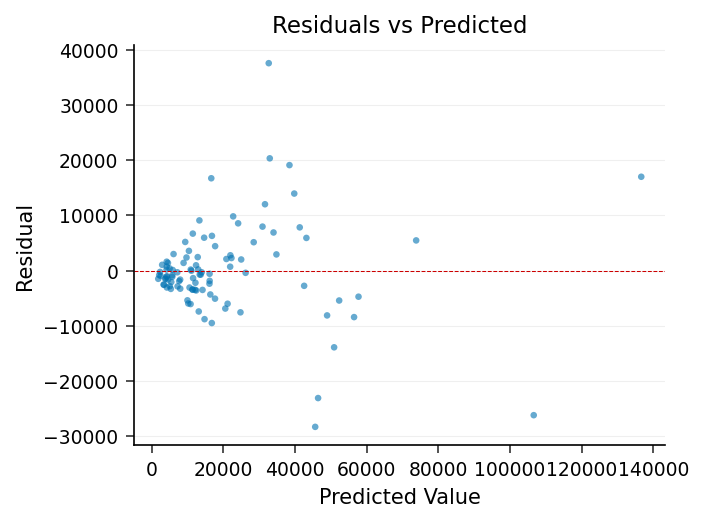

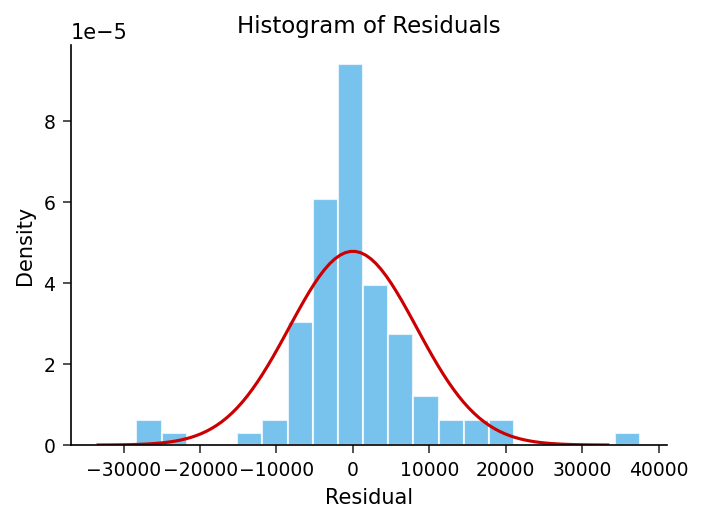

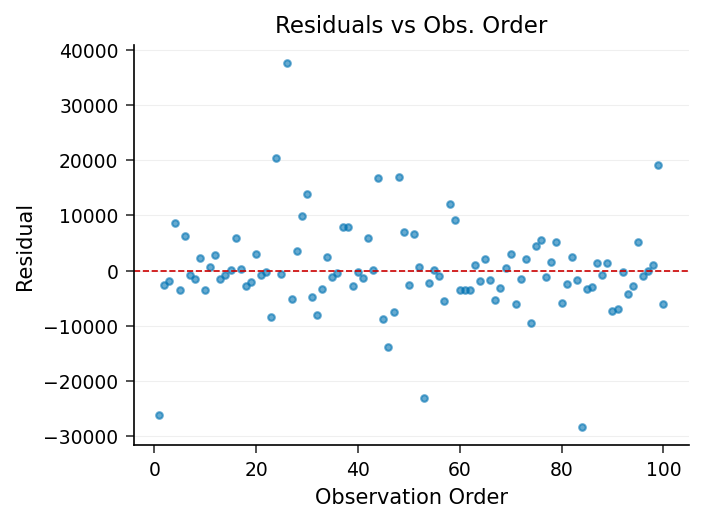

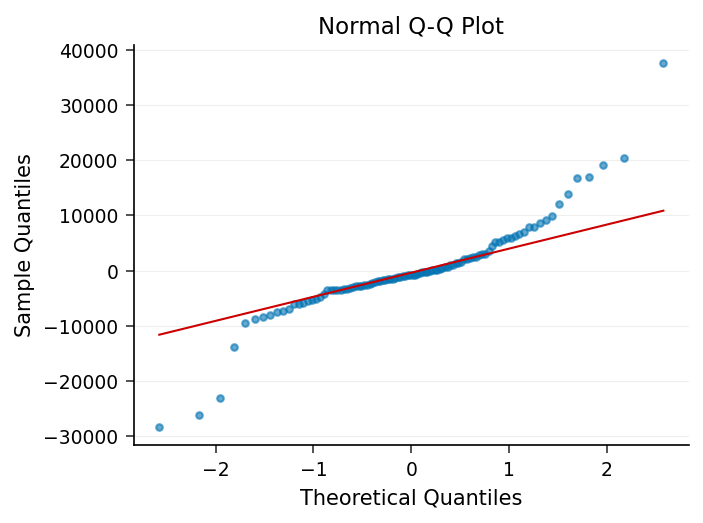

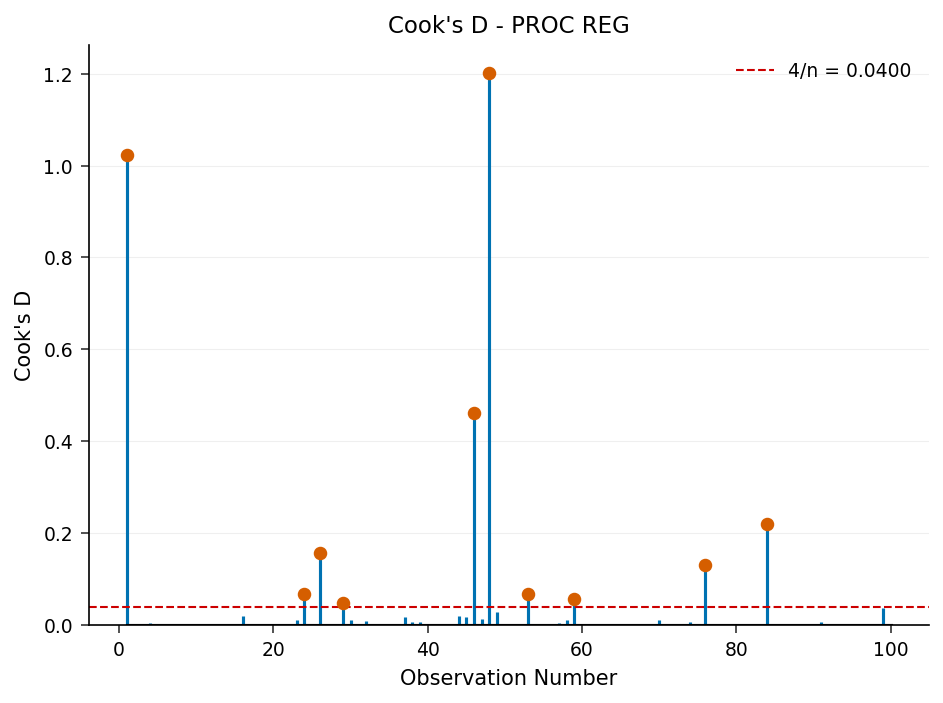

In [5]:
/* --------------------------------------------------------
   Regression: Budget efficiency and conversion drivers
   -------------------------------------------------------- */
proc reg data=campaigns;
    model revenue = budget impressions clicks conversions;
run;


/* force the kernel to flush wrapper-proc output into this cell */
data _reg_done; synced = 1; run;


In [6]:
/* --------------------------------------------------------
   Summary report: Top campaigns by ROAS
   -------------------------------------------------------- */
proc report data=campaigns;
    column channel creative_type budget revenue roas cpa;
    define channel / group;
    define creative_type / group;
    define budget / analysis mean format=dollar10.2;
    define revenue / analysis mean format=dollar10.2;
    define roas / analysis mean format=8.2;
    define cpa / analysis mean format=dollar10.2;
run;


CHANNEL   CREATIVE_TYPE  BUDGET    REVENUE   ROAS      CPA     
email     video          $4,680.17  $45,684.82  11.94     $3.87   
search    carousel       $6,837.75  $22,260.06  1.97      $20.87  
display   text           $3,987.11  $10,227.70  2.49      $20.89  
social    text           $5,531.71  $16,839.88  2.70      $18.79  
display   static         $3,187.62  $7,079.19  2.77      $19.31  
email     carousel       $4,219.45  $29,049.08  8.14      $5.69   
social    static         $3,936.67  $11,826.09  2.87      $18.31  
video     carousel       $4,142.00  $12,913.85  2.66      $17.39  
email     static         $2,935.00  $17,445.86  7.18      $6.28   
social    video          $3,073.62  $17,020.48  5.16      $10.22  
social    carousel       $5,085.80  $12,489.56  2.15      $23.05  
search    video          $6,549.25  $31,152.09  5.29      $9.01   
search    static         $5,145.20  $12,758.82  2.81      $22.63  
video     text           $2,534.80  $7,825.90  3.22      $18.64  


NOTE: PROC REPORT data=campaigns

NOTE: PROC REPORT output 20 observations with 6 variables.

NOTE: Read 100 rows from campaigns.
NOTE: Wrote (console) (20 rows, 6 columns).
NOTE: PROC REPORT elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

## 5. Results

Reading the executed output above, three findings hold up:

- **Channel is the dominant lever.** In the GLM, channel is the only significant term (F = 4.53, p = 0.0024); creative type (p = 0.597), campaign week (p = 0.549), and the channel-by-creative interaction (p = 0.972) are not significant. The model accounts for 46.7% of ROAS variance (R-square = 0.467). The PROC MEANS table makes the channel gap concrete: email averages a ROAS of 9.55 against 2.91 (display), 3.17 (search), 3.46 (social), and 3.14 (video).

- **Email is efficient end to end.** Beyond ROAS, email shows the highest mean CTR (0.0381 vs 0.020-0.024 elsewhere) and the lowest mean CPA ($5.04 vs $16-19 for the other channels) - it converts cheaply, not just at high volume.

- **Video is the best creative format.** Across creative types, video leads on both mean ROAS (6.83) and mean CTR (0.0317), ahead of carousel (4.41 / 0.0253), text (3.22 / 0.0210), and static (3.19 / 0.0200).

- **Revenue tracks conversions, not spend.** The PROC REG model of revenue (R-square = 0.862) finds only the conversions coefficient significant (estimate 31.6, p < .0001). Budget, impressions, and clicks add little once conversions are in the model - spending more does not buy revenue unless it buys conversions.

> **Recommendation:** Treat email and video as the high-efficiency core of the media mix and shift discretionary budget toward them, while recognizing that with only 100 synthetic campaigns the creative-type and interaction effects are directional rather than statistically established.

---

## 6. Export



In [7]:
/* --------------------------------------------------------
   Export campaign performance summary
   -------------------------------------------------------- */
data "campaign_performance.csv";
    set campaigns;
    keep campaign_id channel creative_type budget impressions
         clicks conversions revenue ctr roas cpa;
run;


NOTE: DATA campaign_performance.csv


NOTE: Read 100 rows from campaigns.
NOTE: Wrote campaign_performance.csv (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-bottom: 8px;">&copy; 2026 Jenner Analytics Ltd. All rights reserved. Jenner&trade; is a trademark of Jenner Analytics Ltd.</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 11px; line-height: 1.5;">This notebook is provided for demonstration purposes only. The analysis, data, and findings herein do not constitute marketing, business, or professional advice.</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-top: 8px;">Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a></div>
</div>